# Skin Detector CNN Model Training
This notebook trains a CNN model to classify images as `psoriasis`, `normal skin`, or `invalid` using a balanced dataset.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
# Set paths
base_dir = 'skin-detector-dataset'  # adjust if needed
img_size = 128
batch_size = 32

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=10
)

train_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2271 images belonging to 3 classes.
Found 566 images belonging to 3 classes.


In [4]:
# Compute class weights
class_indices = train_data.class_indices
classes = train_data.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(zip(np.unique(classes), weights))
print("Class Weights:", class_weights)

Class Weights: {0: 0.94625, 1: 0.9142512077294686, 2: 1.177293934681182}


In [5]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Set up callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('skin_detector_model.h5', save_best_only=True)

# Train the model
history = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.5238 - loss: 0.9761

71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 990ms/step - accuracy: 0.5255 - loss: 0.9739 - val_accuracy: 0.8021 - val_loss: 0.4343
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.7975 - loss: 0.5440

71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 924ms/step - accuracy: 0.7975 - loss: 0.5437 - val_accuracy: 0.8763 - val_loss: 0.3115
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 917ms/step - accuracy: 0.8252 - loss: 0.4604 - val_accuracy: 0.8763 - val_loss: 0.3123
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 916ms/step - accuracy: 0.8529 - loss: 0.4019 - val_accuracy: 0.8375 - val_loss: 0.3852
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.8589 - loss: 0.3992

71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 910ms/step - accuracy: 0.8589 - loss: 0.3989 - val_accuracy: 0.8940 - val_loss: 0.2960
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.8611 - loss: 0.3609

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 923ms/step - accuracy: 0.8855 - loss: 0.2960 - val_accuracy: 0.8869 - val_loss: 0.2624
Epoch 9/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 922ms/step - accuracy: 0.9076 - loss: 0.2751 - val_accuracy: 0.9117 - val_loss: 0.2933
Epoch 10/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 921ms/step - accuracy: 0.9103 - loss: 0.2702 - val_accuracy: 0.8534 - val_loss: 0.3659
Epoch 11/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 65s 920ms/step - accuracy: 0.9088 - loss: 0.2534 - val_accuracy: 0.8993 - val_loss: 0.2745
Epoch 12/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 943ms/step - accuracy: 0.9264 - loss: 0.2083 - val_accuracy: 0.8887 - val_loss: 0.2942
Epoch 13/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.9215 - loss: 0.2070

71/71 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9215 - loss: 0.2073 - val_accuracy: 0.8993 - val_loss: 0.2533
Epoch 14/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9260 - loss: 0.2311

71/71 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9260 - loss: 0.2311 - val_accuracy: 0.9134 - val_loss: 0.2392
Epoch 15/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9289 - loss: 0.2034 - val_accuracy: 0.8958 - val_loss: 0.2451
Epoch 16/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9164 - loss: 0.2258 - val_accuracy: 0.8940 - val_loss: 0.2720
Epoch 17/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 69s 977ms/step - accuracy: 0.9233 - loss: 0.2005 - val_accuracy: 0.8622 - val_loss: 0.3304
Epoch 18/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9266 - loss: 0.2109

71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 943ms/step - accuracy: 0.9268 - loss: 0.2105 - val_accuracy: 0.9258 - val_loss: 0.2276
Epoch 19/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.9433 - loss: 0.1697

71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 943ms/step - accuracy: 0.9433 - loss: 0.1698 - val_accuracy: 0.9205 - val_loss: 0.2160
Epoch 20/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 923ms/step - accuracy: 0.9555 - loss: 0.1420 - val_accuracy: 0.8746 - val_loss: 0.3044
Epoch 21/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 67s 936ms/step - accuracy: 0.9321 - loss: 0.2015 - val_accuracy: 0.9064 - val_loss: 0.2361
Epoch 22/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9542 - loss: 0.1427 - val_accuracy: 0.8675 - val_loss: 0.3281
Epoch 23/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9369 - loss: 0.1726 - val_accuracy: 0.8569 - val_loss: 0.3525
Epoch 24/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 925ms/step - accuracy: 0.9459 - loss: 0.1582 - val_accuracy: 0.9152 - val_loss: 0.2263


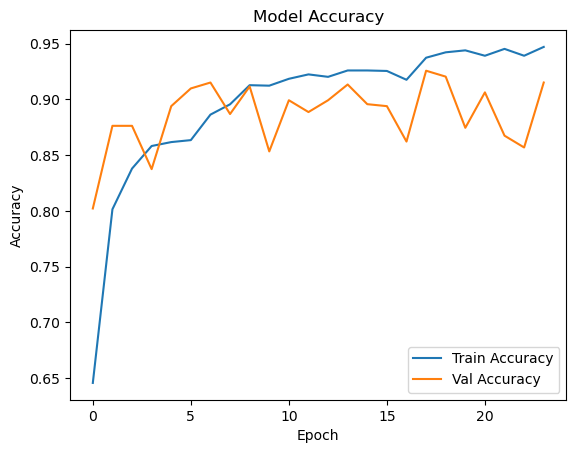

In [7]:
# Plot training results
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()